 # 학습 내용
- AI Agent
- Vision Agent
- 간단한 Vison Agent 구현 (단순 반사 에이전트)
- Gradio를 이용한 웹 서비스 구현
- 시각-언어-행동 통합 Agent 구현 (모델 기반 반사 에이전트)
- Streamlit을 이용한 웹 서비스구현
- 비디오 이해를 위한 Vison Agent 구현 (모델 기반 반사 에이전트)
- Gradio를 이용한 웹 서비스 구현
- Stablediffusion 기반 이미지 생성
- 이미지 생성 Agent 구현
- Streamlit을 이용한 웹 서비스구현

 # Vision Agent 개요
- 많은 AI 에이전트가 NLP를 통한 언어 처리에 중점을 두는 반면, 비전 AI 에이전트는 **컴퓨터 비전을 통합하여 시각 데이터를 처리**
  - Ultralytics YOLO11과 같은 고급 컴퓨터 비전 모델을 사용하여 보다 정밀한 이미지 분석을 수행
- 자율 주행 차량의 비전 AI 에이전트 작동 예시
  - 인식
    - 자율주행차의 비전 AI 에이전트는 차량에 설치된 카메라와 센서에서 시각 데이터를 수집
    - 데이터에는 다른 차량, 보행자, 교통 신호, 도로 표지판 등 주변 환경의 이미지와 비디오가 포함

  - 의사 결정
    - 시각적 데이터를 처리
    - 자동차나 보행자와 같은 물체를 식별하고 장애물이나 갑작스러운 차선 변경을 감지하며 교통 흐름 및 신호 상태와 같은 패턴을 인식
    - 이를 통해 차량이 도로 상황을 실시간으로 파악

  - 행동
    - 분석 결과를 바탕으로 장애물을 피하기 위해 스티어링을 조작하거나 속도를 조절하거나 빨간불에 정지하는 등의 조치를 취함
    - 안전하고 효율적인 운전을 보장하기 위해 신속하게 동작

### 비전 AI 에이전트 유형
- 단순 반사 에이전트
  - 가장 기본적인 유형의 AI 에이전트
  - 과거 기록이나 미래의 결과를 고려하지 않고 순전히 현재 상황에 따라 미리 정의된 동작으로 특정 입력에 응답
  - 일반적으로 간단한 "if-then" 규칙을 사용하여 행동을 안내
    - 이미지 분석과 관련해서는 특정 색상(예: 빨간색)을 감지하여 즉각적인 동작(예: 빨간색 물체 강조 표시 또는 개수 세기)
  - 간단한 작업에는 효과적일 수 있지만 에이전트가 이전 경험을 통해 학습하거나 적응하지 못하기 때문에 더 복잡한 환경에서는 부족

- 모델 기반 반사 에이전트
  - 환경의 내부 모델을 사용하여 상황을 더 잘 이해하기 때문에 단순 반사 에이전트보다 더 발전된 에이전트
  - 누락되거나 불완전한 정보를 처리하고 더 많은 정보를 바탕으로 의사 결정 처리
  - AI 보안 카메라 시스템을 예
    - 카메라에 통합된 비전 AI 에이전트는 컴퓨터 비전을 사용하여 실시간으로 일어나는 일을 분석
    - 움직임과 행동을 정상적인 행동 모델과 비교하여 도난과 같은 비정상적인 활동을 발견하고 잠재적인 보안 위협을 더 정확하게 포착

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/AI/인사교_LangChain_20260624

/content/drive/MyDrive/AI/인사교_LangChain_20260624


In [3]:
# bitsandbytes : 양자화 라이브러리
# pyngrok : 터널링 도구
!pip install -qU ultralytics openai bitsandbytes streamlit pyngrok

# qwen_vl_utils : Qwen 모델에서 이미지·비디오 전처리 및 입력 변환을 돕는 유틸리티 모듈
# av : Python 바인딩을 제공하는 FFmpeg 래퍼 (비디오/오디오 파일 디코딩 & 인코딩,
#      프레임 단위 접근, 다양한 코덱(H.264, VP9 등) 지원, FFmpeg과 동일한 강력한 포맷 호환성)
!pip install -q qwen_vl_utils av

!pip install -q diffusers

!pip install -qU langchain>=1.0.0 langchain-community langchain-experimental langchain-text-splitters langchain_tavily
!pip install -qU langchain-openai langchain-google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 50.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.5/120.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

In [4]:
import os

In [5]:
with open("/content/drive/MyDrive/AI/인사교_LangChain_20260624/key/openai_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['OPENAI_API_KEY'] = api_key

In [6]:
with open("/content/drive/MyDrive/AI/인사교_LangChain_20260624/key/google_api_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['GOOGLE_API_KEY'] = api_key

In [7]:
import matplotlib.pyplot as plt
import cv2, base64, time, os, torch, io, json, re
from PIL import Image
import numpy as np
from tqdm import tqdm
import base64

from ultralytics import YOLO
from openai import OpenAI
# import google.generativeai as genai #구버전 SDK
# 아래 두개는 google 신버전 SDK
from google import genai
from google.genai import types

# AI 모델을 웹 데모로 손쉽게 만드는 라이브러리
import gradio as gr
from pyngrok import ngrok
from pathlib import Path

from transformers import CLIPProcessor, CLIPModel
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
# 양자화
from transformers import BitsAndBytesConfig

# 모델에 대한 비디오 데이터 준비
from qwen_vl_utils import process_vision_info
from diffusers import StableDiffusionPipeline
from diffusers import StableDiffusion3Pipeline

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [8]:
 # 라이브러리 import
from uuid import uuid4

# 타입 설정
# Sequence : 메시지들의 순서 있는 시퀀스(리스트) 객체 (list 또는 tuple 형태로 메시지를 저장)
# Literal : 값 자체를 타입으로 제한할 수 있도록 해주는 기능
from typing import Annotated, TypedDict, Dict, List, Sequence, Literal, Any
# pydantic : Python 데이터 검증과 설정 관리를 위한 라이브러리
from pydantic import Field, BaseModel, ValidationError

# 상태, 노드
# 노드 : 그래프에서의 작업 단위, 실제 작업을 수행하는 함수
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
# 도구를 노드로 만드는 기능 (자동 맵핑, 상태업데이트, 다중 실행)
from langgraph.prebuilt import ToolNode
# 도구 노드의 결과에 따라 자동으로 라우팅 경로를 설정
from langgraph.prebuilt import tools_condition

# 메모리 저장소
from langgraph.checkpoint.memory import MemorySaver

# 실행 설정
from langchain_core.runnables import RunnableConfig

# 시각화
from IPython.display import Image, display, Markdown

In [9]:
from langchain.tools import tool # 에이전트가 스스로 선택하는 도구
# 모델 연동
import openai
from langchain.chat_models import init_chat_model
from langchain_openai.embeddings import OpenAIEmbeddings

# 프롬프트
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# 메모리 기능
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.messages import HumanMessage, AIMessage

from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

/tmp/ipykernel_152/408515407.py:12: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.chat_message_histories import ChatMessageHistory


### 간단한 Vision Agent 구현 (단순 반사 에이전트)
- 이미지에서 설정된 객체가 탐지되면 알림을 출력하는 Agent

- 상태정의

In [10]:
from typing import TypedDict

class VisionState(TypedDict) :
  model_path : Annotated[str , "model version"]
  image_path : Annotated[str , "image path"]
  detections : Annotated[List[Dict[str,str]], "detections results"]
  target : Annotated[str, "target class name"]
  threshold : Annotated[float, "confidence threshold"]
  target_detected : Annotated[str, "target detected result, yes or no"]
  origin_image : Annotated[str, 'origin image']

- 인식노드 정의

In [11]:
def VisionPerception(s: VisionState) -> VisionState:
  # 모델생성
  model = YOLO(s['model_path'])
  # 모델추론
  results = model(s['image_path'])
  # 인식모델의 추론정보 추출하기
  detections = [] # 추론결과를 담을 리스트

  for box in results[0].boxes :
    # 검출된 객체의 첫번째 인덱스 값을 반환(가장 신뢰도가 높은 값)
    cls_id = int(box.cls[0].item())
    # 검출객체의 인덱스를 라벨로 변환
    label = model.names[cls_id]
    # 객체에 대한 확신도 추출
    conf = float(box.conf[0].item())
    # 객체의 위치정보 추출
    x1,y1,x2,y2 = box.xyxy[0]

    # 추출된 결과값을 리스트에 저장
    detections.append({'label':label, "confidence": f"{conf:2f}",
                       'x1' : str(int(x1)), 'y1' : str(int(y1)),
                       'x2' : str(int(x2)), 'y2' : str(int(y2))})

    # 오리진 이미지 추출
    img = results[0].orig_img.copy()
    # numpy 배열을 base64로 직렬화
    _, buffer = cv2.imencode(".png", img)
  base64_encoded = base64.b64encode(buffer)
  base64_string = base64_encoded.decode('utf-8')

  return VisionState(detections = detections, origin_image = base64_string)

- 의사결정 노드 정의

In [12]:
def DecisionMake(s:VisionState) -> VisionState :
  for d in s['detections'] : #  상태에서 인식된 객체검출 결과를 반복처리
    # 지정된 클래스 이름과 같고 확신도 임계치를 넘는 경우
    if d['label'] == s['target'] and float(d['confidence']) >= s['threshold'] :
      print(F"======[target detected] 지정된 {s['target']}이 검출되었습니다.")
      return VisionState(target_detected = 'yes')
  return VisionState(target_detected = 'no')

- 행동 노드 정의

In [13]:
def AgentAction(s:VisionState) -> VisionState :
  # 메세지 발송
  if s['target_detected'] == 'yes' :
    print("알림 발생, 지정된 메세지가 발송됩니다.")
  # 검출된 객체 이미지 출력
  ## base64 to image
  img_bytes = base64.b64decode(s['origin_image'])
  nparr = np.frombuffer(img_bytes, np.uint8)
  img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

  ## 색공간 변환 BGR -> RGB
  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  # 사각형 그리기
  for d in s['detections'] :
    if d['label'] == s['target'] and float(d['confidence']) >= s['threshold'] :
      cv2.rectangle(img_rgb, # 그림을 그릴 이미지
                    (int(d['x1']), (int(d['y1']))), # 시작 좌표
                    (int(d['x2']), (int(d['y2']))) , # 끝 좌표
                    (0,255,0), # 선 색상
                    2) # 선 두께
  plt.imshow(img_rgb)
  plt.axis('off')
  plt.show()

  return VisionState() # 추후에 탐지결과 이미지를 state에 업데이트하는 것도 고려

- 그래프 구축

In [14]:
# 그래프 베이스 생성
workflow = StateGraph(VisionState)

# 노드 정의
workflow.add_node("VisionPerception", VisionPerception)
workflow.add_node("DecisionMake", DecisionMake)
workflow.add_node("AgentAction", AgentAction)

# 엣지 정의
workflow.add_edge(START, "VisionPerception")
workflow.add_edge("VisionPerception", "DecisionMake")
workflow.add_edge("DecisionMake", "AgentAction")
workflow.add_edge("AgentAction",END)

# 컴파일
app = workflow.compile()


image 1/1 /content/drive/MyDrive/AI/인사교_LangChain_20260624/data/bus.png: 384x640 10 persons, 1 car, 1 bus, 2 backpacks, 1012.5ms
Speed: 20.6ms preprocess, 1012.5ms inference, 64.2ms postprocess per image at shape (1, 3, 384, 640)
======[target detected] 지정된 bus이 검출되었습니다.
알림 발생, 지정된 메세지가 발송됩니다.


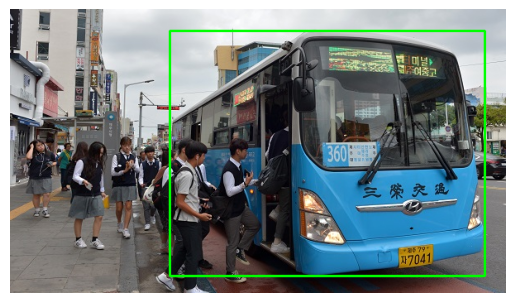

In [15]:
# 그래프 실행
input = VisionState(
    model_path = "model/yolo12n.pt",
    image_path = "./data/bus.png",
    target = "bus",
    threshold = 0.7
)
rs = app.invoke(input = input)

In [16]:
rs

{'model_path': 'model/yolo12n.pt',
 'image_path': './data/bus.png',
 'detections': [{'label': 'bus',
   'confidence': '0.940172',
   'x1': '193',
   'y1': '26',
   'x2': '574',
   'y2': '322'},
  {'label': 'person',
   'confidence': '0.841970',
   'x1': '176',
   'y1': '159',
   'x2': '248',
   'y2': '340'},
  {'label': 'person',
   'confidence': '0.759125',
   'x1': '121',
   'y1': '153',
   'x2': '155',
   'y2': '278'},
  {'label': 'person',
   'confidence': '0.753060',
   'x1': '71',
   'y1': '159',
   'x2': '117',
   'y2': '291'},
  {'label': 'person',
   'confidence': '0.747943',
   'x1': '16',
   'y1': '156',
   'x2': '57',
   'y2': '252'},
  {'label': 'car',
   'confidence': '0.716762',
   'x1': '562',
   'y1': '171',
   'x2': '600',
   'y2': '206'},
  {'label': 'person',
   'confidence': '0.710203',
   'x1': '248',
   'y1': '155',
   'x2': '294',
   'y2': '331'},
  {'label': 'person',
   'confidence': '0.535492',
   'x1': '151',
   'y1': '164',
   'x2': '182',
   'y2': '270'},


# 시각-언어-행동 통합 Agent 구현(모델 기반 반사 에이전트)
- InputImage : 이미지를 읽는 역할
- VisionAnalysis : 비전 모델을 활용하여 이미지를 분석하는 역할
- captionExtract : GPT 모델을 활용하여 이미지를 설명하는 역할
- ActionExecute : 시각적,언어적 입력을 기반으로 다음 행동을 선택하는 역할

- 상태정의

In [17]:
from typing import TypedDict
class VisionAgentState(TypedDict) :
  image_path : Annotated[str, "input image path"]
  origin_image : Annotated[str, "origin image data"]
  model_path : Annotated[str, "model version"]
  detections : Annotated[List[Dict[str,str]], "detections results"]
  caption_text : Annotated[str, "caption result"]

- 이미지 입력 노드

In [18]:
def InputImage(s:VisionAgentState) -> VisionAgentState :
  # 이미지 오픈
  img = cv2.imread(s['image_path'])

  if img is None :
    return VisionAgentAgentState(origin_image ="None") # 이미지가 오픈되지 않는 경우 처리
  else :
    # base64로 직렬화
    _, buffer = cv2.imencode(".jpg", img)
    base64_encoded = base64.b64encode(buffer)
    base64_string = base64_encoded.decode('utf-8')

    return VisionAgentState(origin_image = base64_string)

- 이미지 분석 노드

In [19]:
def VisionAnalysis(s:VisionAgentState) -> VisionAgentState :
 # 모델 생성
 model = YOLO(s['model_path'])
 # 모델 추론
 ## base64 to image
 img_bytes = base64.b64decode(s['origin_image'])
 nparr = np.frombuffer(img_bytes, np.uint8)
 img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
 results = model(img)
 # 예측정보 추출(정리)
 detections = [] # 추론결과를 담을 리스트

 for box in results[0].boxes :
    # 검출된 객체의 첫번째 인덱스 값을 반환(가장 신뢰도가 높은 값)
    cls_id = int(box.cls[0].item())
    # 검출객체의 인덱스를 라벨로 변환
    label = model.names[cls_id]
    # 객체에 대한 확신도 추출
    conf = float(box.conf[0].item())
    # 객체의 위치정보 추출
    x1,y1,x2,y2 = box.xyxy[0]

    # 추출된 결과값을 리스트에 저장
    detections.append({'label':label, "confidence": f"{conf:2f}",
                       'x1' : str(int(x1)), 'y1' : str(int(y1)),
                       'x2' : str(int(x2)), 'y2' : str(int(y2))})
 return VisionAgentState(detections=detections)

- 이미지 설명 노드

In [20]:
def CaptionExtract(s:VisionAgentState) -> VisionAgentState :
  prompt = f'''
      당신은 위험 상황을 감지하는 vision AI 입니다.
      아래 객체 탐지결과(detected_results)를 참고하여
      이미지의 상황을 설명하는 caption text를 구성하세요.
      caption text는 5줄 이내로 작성하세요.

      detected_results : {s['detections']}
    '''
  #OpenAI모델 생성 및 멀티모달 추론 호출
  client = OpenAI()
  response = client.responses.create(
      model="gpt-4o", # 모델이름
      input=[
          {
              'role' : 'user',
              "content" : [
                  {"type":"input_text", "text" : prompt},
                  {"type":"input_image", "image_url" : f"data:image/jpg;base64,{s['origin_image']}"}
              ]
          }
      ]
  )

  return VisionAgentState(caption_text=response.output_text)

- 행동 노드

In [21]:
import requests

In [22]:
# tool 정의
@tool
def send_message(msg : str) :
  '''이미지 caption 결과 위험한 상황이면 메세지 송신 '''
  WEBHOOK_URL = "https://discordapp.com/api/webhooks/1523877416626290738/nCS8MmkImtT-QnCwEP6pSa83sbzN2C4CAx_DNHoX2XSzX7OtAsU7ZNGPgXh16Szba24c"

  response = requests.post(
      WEBHOOK_URL,
      json={
          "content": msg
      }
  )


In [23]:
def ActionExecute(s:VisionAgentState) -> VisionAgentState :
  # 모델생성
  llm = init_chat_model(model="openai:gpt-4o-mini", max_tokens=500, temperature=0)
  # 도구연결
  llm_with_tools = llm.bind_tools([send_message])
  # 프롬프트 템플릿 구성
  template = ChatPromptTemplate.from_messages([
      ('system', '''
      너는 위험상황에 따라 action을 취하는 Vision AI야
      아래 caption text와 detections를 보고 위험상황에 대해서 경고메세지를 송신하거나
      안전한 경우 현재 상황을 설명하는 리포트를 구성해줘.

      caption text : {caption_text}

      detections : {detections}
      ''')
  ])
  # 체인구성하기
  action_chain = template | llm_with_tools
  # 체인호출
  rs = action_chain.invoke({
      'caption_text' : s['caption_text'],
      'detections' : s['detections']
  })
  # tool 호출하기
  tool_map = {
      "send_message" : send_message
  }
  for tool_call in rs.tool_calls :
    tool = tool_map[tool_call['name']]
    tool.invoke(tool_call['args'])

  # 문자열메세지 파싱
  parser = StrOutputParser()
  output = parser.invoke
  print(output)

  return VisionAgentState()

- 그래프 구성

In [24]:
# 그래프 베이스 생성
workflow = StateGraph(VisionAgentState)
# 노드 정의
workflow.add_node("InputImage", InputImage)
workflow.add_node("VisionAnalysis", VisionAnalysis)
workflow.add_node("CaptionExtract", CaptionExtract)
workflow.add_node("ActionExecute", ActionExecute)
# 엣지 정의
workflow.add_edge(START, "InputImage")
workflow.add_edge("InputImage", "VisionAnalysis")
workflow.add_edge("VisionAnalysis", "CaptionExtract")
workflow.add_edge("CaptionExtract","ActionExecute")
workflow.add_edge("ActionExecute",END)
# 컴파일
app = workflow.compile()

In [25]:
# 실행
input = VisionAgentState(
    model_path = "model/yolo12n.pt",
    image_path = "./data/bus.png",
)
rs = app.invoke(input=input)


0: 384x640 10 persons, 1 car, 1 bus, 1 backpack, 342.6ms
Speed: 4.7ms preprocess, 342.6ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)
<bound method BaseOutputParser.invoke of StrOutputParser()>


In [26]:
rs

{'image_path': './data/bus.png',
 'origin_image': '...',
 'model_path': 'model/yolo12n.pt',
 'detections': [{'label': 'bus',
   'confidence': '0.939452',
   'x1': '193',
   'y1': '27',
   'x2': '574',
   'y2': '322'},
  {'label': 'person',
   'confidence': '0.839316',
   'x1': '176',
   'y1': '159',
   'x2': '247',
   'y2': '341'},
  {'label': 'person',
   'confidence': '0.759318',
   'x1': '121',
   'y1': '153',
   'x2': '155',
   'y2': '277'},
  {'label': 'person',
   'confidence': '0.757841',
   'x1': '71',
   'y1': '159',
   'x2': '118',
   'y2': '290'},
  {'label': 'person',
   'confidence': '0.752404',
   'x1': '16',
   'y1': '155',
   'x2': '57',
   'y2': '252'},
  {'label': 'person',
   'confidence': '0.710934',
   'x1': '247',
   'y1': '155',
   'x2': '294',
   'y2': '331'},
  {'label': 'car',
   'confidence': '0.708481',
   'x1': '562',
   'y1': '171',
   'x2': '600',
   'y2': '206'},
  {'label': 'person',
   'confidence': '0.551562',
   'x1': '152',
   'y1': '164',
   'x2': 

# 비디오 분석 Vision Agent

### 학습 내용
- CLIP를 활용한 비디오 유해성 판단
- Gemini를 활용한 비디오 유해성 근거 설명
- Qwen2.5-VL을 활용한 정상 비디오 요약
- 엔드투엔드 솔루션에 필요한 감지 → 설명 → 요약 파이프라인 구축

<center>  
<img src="https://arome1004.cafe24.com/images/cv_project/lecture_image/video_understand.png" width=50%>
</center>

### CLIP (Contrastive Language-Image Pre-training)
- **Contrastive Learning**
  - 레이블링 없이 학습하는 비지도 학습(Self-supervised Learning)
  - 특정 입력을 Embedding Network를 통해 임베딩 공간으로 이동시키고, 같은 class라면 임베딩 값의 거리를 최소화(d+)하고, 다른 class라면 임베딩 값의 거리를 최대화 (d-) 되도록 embedding network를 학습


<center>  
<img src="https://arome1004.cafe24.com/images/cv_project/lecture_image/clip01.png" width=40%> <br><font size=1>출처 : https://xoft.tistory.com/67</font>  
</center>    

- CLIP 모델은 2021년에 OpenAI에서 개발한 모델
- 4억개 이미지와 해당 이미지에 대한 설명 Text를 pair로 두고 학습데이터셋으로 구성한 후, 각각을 인코더로 임베딩하여 같은 pair에 대해 거리를 가깝게하고 다른 pair에 대해 거리가 멀어지도록 텍스트/이미지 인코더를 학습


<center>  
<img src="https://arome1004.cafe24.com/images/cv_project/lecture_image/clip02.png" width=40%> <br><font size=1>출처 : https://openai.com/index/clip/</font>  
</center>     

### CLIP 모델로딩

In [18]:
clip_checkpoint = "openai/clip-vit-base-patch32"
model_clip = CLIPModel.from_pretrained(clip_checkpoint)
processor_clip = CLIPProcessor.from_pretrained(clip_checkpoint)
# GPU 자원이 확보된 환경인 경우에 따른 처리
clip_device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_clip = model_clip.to(clip_device)
print("CLPIP device : ", clip_device)

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLPIP device :  cpu


###Qwen2.5-VL 모델 다운로드

In [41]:
if torch.cuda.is_available(): # GPU 사용이 가능한 경우
  quant_config = BitsAndBytesConfig(
            load_in_4bit=True, # 모델저장을 16비트를 4비트로 줄임 -> 약간의 성능저하, 속도 향상
            bnb_4bit_compute_dtype=torch.float16, # 연산(추론)은 잠깐 16bit로 복원해서 진행
            bnb_4bit_use_double_quant=True, # 양자화 활성화
            bnb_4bit_quant_type="nf4", # 정규분포 형태로 노말라이즈
        )
  # 모델 다운로드 (with quantization)
  model_qwen = Qwen2_5_VLForConditionalGeneration.from_pretrained(
      "Qwen/Qwen2.5-VL-3B-Instruct",
      torch_dtype = 'auto',
      device_map= 'auto',
      quantization_config = quant_config
  )
else: # GPU 사용이 불가능한 경우
   # 모델 다운로드 (without quantization, to CPU)
  model_qwen = Qwen2_5_VLForConditionalGeneration.from_pretrained(
      "Qwen/Qwen2.5-VL-3B-Instruct",
      torch_dtype = 'auto',
      device_map= 'cpu'
  )

processor_qwen = AutoProcessor.from_pretrained('Qwen/Qwen2.5-VL-3B-Instruct')
model_qwen.eval() # 추론모드 설정

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear(in_features=1280, out_features=3840, bias=True)
            (proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
            (act_f

# Vision Function 정의

In [11]:
def extract_frames(video_path : str) -> list[tuple[int,str]] :
 '''비디오에서 전체 프레임을 추출하는 함수'''
 cap = cv2.VideoCapture(video_path)
 if not cap.isOpened() :
   raise ValueError(f"비디오 파일을 열 수 없습니다. : {video_path}")

 frames = [] # 프레임을 담을 리스트
 idx = 0 # 프레임 번호를 관리할 변수

 while True :
   ret, frame = cap.read() # 비디오 프레임 읽기
   if ret == False :
     break
   # 색공관 변환
   rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
   # base64 직렬화
   _, buffer = cv2.imencode(".jpg", rgb_frame)
   base64_encoded = base64.b64encode(buffer)
   base64_string = base64_encoded.decode('utf-8')
   # 리스트에 추가
   frames.append((idx,base64_string))
   idx += 1
 cap.release()
 return frames

In [12]:
# 테스트
frames = extract_frames("./data/face_1s.mp4")

In [13]:
frames [0:2]

[(0,
  '...'),
 (1,
  '...')]

In [14]:
def sample_frames(frames:list[tuple[int,str]], step:int=10) -> list[tuple[int]]:
 ''' 긴 영상 처리를 줄이기 위해 일정 간격으로 프레임을 샘플링 '''
 if step <=0 :
  raise ValueError("step은 1 이상으로 설정")

 return frames[::step]

In [15]:
sampling_frames = sample_frames(frames, step=10)
sampling_frames

[(0,
  '...'),
 (10,
  '...'),
 (20,
  '...')]

In [16]:
def classify_frame_with_clip(frame:str) -> tuple[str,float] :
  ''' CLIP으로 단일 프레임의 유해성 라벨과 신뢰도를 측정 '''
  # CLIP은 문장과 이미지 pair로 학습했기 때문에 문장형태로 넣어주는게 좋다
  text_inputs = [
      "이 이미지는 정상입니다.",
      "이 이미지에는 누드가 포함되어 있습니다.",
      "이 이미지에는 유혹적이거나 감각적인 내용이 포함되어 있습니다.",
      "이 이미지에는 폭력적인 내용이 포함되어 있습니다."
  ]
  # 추론 결과를 표현할 카테고리 클래스
  labels = ['정상', '누드', '유혹적 또는 감각적', '폭력적']
  # 전처리
  ## base64 to image
  img_bytes = base64.b64decode(frame)
  nparr = np.frombuffer(img_bytes, np.uint8)
  img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

  inputs = processor_clip(
      text=text_inputs,
      images=img,
      return_tensors='pt',
      padding=True
  ).to(clip_device)
  # 모델추론
  with torch.no_grad():
    outputs = model_clip(**inputs)
  #다중분류 확률값으로 변경
  probs = outputs.logits_per_image.softmax(dim=-1)
  # 제일 높은 확률 값과 클래스 번호 추출
  conf, pred_class = probs.max(dim=-1)
  return labels[pred_class.item()], float(conf.item())

In [19]:
rs = classify_frame_with_clip(sampling_frames[0][1])

In [20]:
rs

('유혹적 또는 감각적', 0.48535865545272827)

In [21]:
def analyze_video_safety(
    sampled_frames:list[tuple[int,str]],
    threshold:float = 0.25
    ) -> tuple[str, float, list[dict[str,Any]],list[str]] :
    ''' 샘플링된 프레임을 검사하고 유해 프레임 목록을 반환 '''
    flagged_data = [] # 유해성 검사 결과 데이터 리스트
    flagged_frames = [] # 유해성 검사 결과 프레임 리스트

    for frame_id, b64str in tqdm(sampled_frames) : # 샘플링된 프레임 반복처리
      label, conf = classify_frame_with_clip(b64str) # 한 프레임 유해성 검증
      if label != '정상' and conf >= threshold :
        flagged_data.append({
            'frame_id' : frame_id, # 프레임 번호
            'classification' : label, # 유해성 검증 결과, 분류 결과
            'confidence' : conf # 확신도(신뢰도)
        })
        flagged_frames.append(b64str) # 프레임 추가
    # 영상에 대한 종합 판단 라벨링
    safety_label = 'unsafe' if flagged_frames else 'safe'
    # 유해한 프레임 비율 계산
    unsafe_ratio = len(flagged_frames) / len(sampled_frames) * 100
    # 결과반환
    return safety_label, unsafe_ratio, flagged_data, flagged_frames

In [22]:
rs = analyze_video_safety(sampling_frames, threshold=0.25)

100%|██████████| 3/3 [00:01<00:00,  1.76it/s]


In [23]:
rs

('unsafe',
 100.0,
 [{'frame_id': 0,
   'classification': '유혹적 또는 감각적',
   'confidence': 0.48535865545272827},
  {'frame_id': 10,
   'classification': '유혹적 또는 감각적',
   'confidence': 0.3654949963092804},
  {'frame_id': 20,
   'classification': '유혹적 또는 감각적',
   'confidence': 0.4295578598976135}],
 ['...'])

In [26]:
# gemini를 활용한 유해성 설명 함수
# 재사용 가능하도록 함수 바깥에서 생성
client = genai.Client(api_key=api_key)
# base64 -> 바이트이미지
def base64_to_image(base64_str) :
  ''' base64 이미지데이터를 gemini가 인식하는 데이터형태로 감싸서 반환'''
  img_bytes = base64.b64decode(base64_str)
  return types.Part.from_bytes(
      data = img_bytes,
      mime_type = "image/jpeg"
  )
def explain_flagged_frames(
    flagged_data: list[dict[str,Any]],
    flagged_frames: list[str] ) :

  ''' 유해성을 설명하도록 요청하는 함수 '''

  prompt = f'''
    다음은 비디오에서 유해할 수 있다고 분류된 프레임 정보입니다.

    {json.dumps(flagged_data, indent=2)}

    각 프레임의 이미지를 함께 보고 다음 내용을 2~3문장으로 설명하세요.

    1. 어떤 장면으로 보이는지
    2. 왜 유해 콘텐츠로 판단되었을 가능성이 있는지
    3. 오탐 가능성 또는 모델 판단의 한계

    주의:
      - 단정적으로 말하지 마세요.
      - 이미지에서 보이는 정보만 근거로 설명하세요.
      - 확실하지 않은 경우 '추정'이라고 표현하세요.
  '''

  content = []
  content.append(prompt) # 유해성 메타데이터 및 프롬프트 추가
  for s in flagged_frames : # 유해성 이미지 반복처리
    content.append(base64_to_image(s)) # base64->이미지타입으로 변경 후 추가

  # 모델 추론 -> 나중에는 많은 프레임을 보내지 않도록 알고리즘 고려
  # 나눠서 여러번 보내는 방식도 고민해도 좋음
  response = client.models.generate_content(
      model = "gemini-2.5-flash",
      contents = content
  )
  return response.text.strip()

In [27]:
#test = [{"key":"hello", "dump":10},
#        {"key2":"hello2", "dump2":20}]
#json.dumps(test)

In [28]:
explain_flagged_frames(rs[2],rs[3])

'본 비디오 프레임들은 파란색 조명 아래에서 두 명의 젊은 여성이 친밀하게 포즈를 취하고 있는 장면으로 보입니다. 모델은 두 여성의 밀착된 자세, 드러난 어깨와 팔, 그리고 다소 감각적으로 연출된 조명 효과 때문에 해당 장면을 유혹적 또는 감각적인 콘텐츠로 추정했을 가능성이 있습니다. 그러나 낮은 신뢰도와 함께 이는 우정 표현이나 일반적인 패션 스타일이 모델에 의해 오인된 오탐일 가능성이 높습니다.'

In [46]:
def summarize_video_qwen(video_path) :
  '''정상 영상인 경우 Qwen2.5-VL로 비디오 요약'''
  # Qwen 모델을 위한 video path 타입으로 생성
  vpath = Path(video_path).resolve()
  # 요청할 메세지 구성
  messages = [
      {
        "role" : "user",
        "content" : [
            {'type':"video", "video" : f"file://{vpath}"},
            {"type": "text", "text": (
                "이 영상을 한글로 요약하세요. "
                "반드시 JSON 형식으로 반환하세요. "
                "키는 bullets와 paragraph만 사용하세요. "
                "bullets는 5개 이내의 문자열 리스트, paragraph는 짧은 문단입니다."
            )}
        ]
      }
   ]
  # 전처리 작업 실시
  text = processor_qwen.apply_chat_template(
          messages,
          tokenize=False,
          add_generation_prompt=True,
      )
  image_inputs, video_inputs = process_vision_info(messages)

  inputs = processor_qwen(
      text=[text],
      images=image_inputs,
      videos=video_inputs,
      return_tensors="pt",
  ).to(model_qwen.device)

  # 모델 추론
  with torch.no_grad():
      output_ids = model_qwen.generate(**inputs, max_new_tokens=512)

  trimmed = [
      out_ids[len(in_ids):]
      for in_ids, out_ids in zip(inputs.input_ids, output_ids)
  ]
  # 추론한 토큰숫자 값을 글자로 복원하여 반환 (batch_decode)
  return processor_qwen.batch_decode(trimmed, skip_special_tokens=True)[0].strip()

In [47]:
rs = summarize_video_qwen("./data/face_1s.mp4")

qwen-vl-utils using torchcodec to read video.


In [48]:
rs

'{\n  "bullets": [\n    "Two women posing together",\n    "Sunlight casting shadows on their faces",\n    "One woman wearing a pink top",\n    "The other woman wearing a red top",\n    "Both women smiling"\n  ],\n  "paragraph": "The image features two women standing close to each other, with sunlight creating dramatic shadows on their faces. The woman on the left is wearing a pink top, while the woman on the right is in a red top. Both women are smiling and appear to be enjoying the moment."\n}'

### Graph 구성하기(실습)
- 프레임 추출, 프레임샘플링, 비디오 유해성 분석 노드 3가지 그래프로 구성해보기


- 상태(State)구성하기

In [29]:
class VisionAgentState(TypedDict) :
  video_path : Annotated[str, "video path"]
  frames : Annotated[List[tuple[int,str]], "frames"]
  step : Annotated[int, "frame_sampling_step"]
  sampled_frames : Annotated[list[tuple[int,str]], "sampled frames"]
  threshold : Annotated[float, "safety threshold"]
  safety_label : Annotated[str, "label : safe or unsafe"]
  unsafe_ratio : Annotated[float, "unsafe ratio"]
  flagged_data : Annotated[List[Dict[str,Any]], "flagged frame data"]
  flagged_frames : Annotated[List[str], "flagged frames"]

- 노드 구성

In [30]:
# 프레임 추출 노드
def extract_node(s:VisionAgentState) -> VisionAgentState :
  frames = extract_frames(s['video_path'])
  return VisionAgentState(frames=frames)

# 샘플링 노드
def sample_node(s:VisionAgentState) -> VisionAgentState :
  sampled_frames = sample_frames(s['frames'], s['step'])
  return VisionAgentState(sampled_frames = sampled_frames)

#유해성 분석 노드
def safety_check_node(s:VisionAgentState) -> VisionAgentState :
  l, r, m, f = analyze_video_safety(s['sampled_frames'], s['threshold'])
  return VisionAgentState(
      safety_label = l, # 유해성 최종라벨(문자열)
      unsafe_ratio = r, # 유해한 프레임비율(실수)
      flagged_data = m, # 유해한 프레임에 대한 정보 (딕셔너리)
      flagged_frames = f # 유해한 프레임이미지 (리스트. 문자열)
  )

- 그래프 구성

In [31]:
# 그래프 베이스 생성
workflow = StateGraph(VisionAgentState)
# 노드 정의
workflow.add_node("extract_node", extract_node)
workflow.add_node("sample_node", sample_node)
workflow.add_node("safety_check_node", safety_check_node)

# 엣지 추가
workflow.add_edge(START, "extract_node")
workflow.add_edge("extract_node", "sample_node")
workflow.add_edge("sample_node", "safety_check_node")
workflow.add_edge("safety_check_node",END)

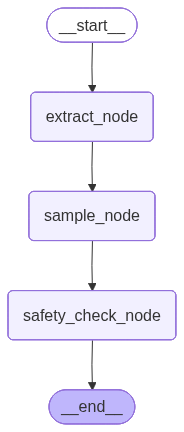

In [36]:
display(Image(app.get_graph().draw_mermaid_png()))

In [32]:
# 컴파일
app = workflow.compile()

# 실행
input = VisionAgentState(
    video_path = "./data/face_1s.mp4",
    step = 10,
    threshold = 0.25
)
rs = app.invoke(input=input)

100%|██████████| 3/3 [00:01<00:00,  1.57it/s]


In [35]:
display(rs)

Output hidden; open in https://colab.research.google.com to view.